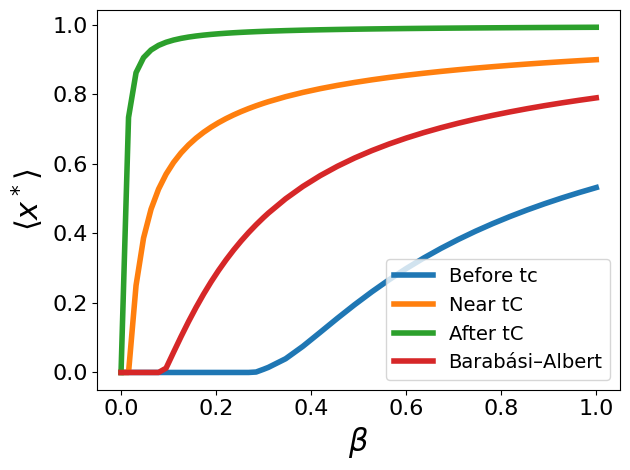

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# load beta axis
beta_values = np.concatenate((np.linspace(0, 0.3, 20),
                              np.linspace(0.31,1,20)))

# load saved steady-state results
before = np.load("before_xstar.npy")
near   = np.load("near_xstar.npy")
after  = np.load("after_xstar.npy")
ba     = np.load("ba_xstar.npy")


# -------------------------------
# COMPARE 4 CURVES
# -------------------------------

plt.figure()
plt.plot(beta_values, before, lw=4, label="Before tc")
plt.plot(beta_values, near,   lw=4, label="Near tC")
plt.plot(beta_values, after,  lw=4, label="After tC")
plt.plot(beta_values, ba,     lw=4, label="Barabási–Albert")

plt.xlabel(r"$\beta$", fontsize=22, fontweight="bold")
plt.ylabel(r"$\langle x^* \rangle$", fontsize=22, fontweight="bold")

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()


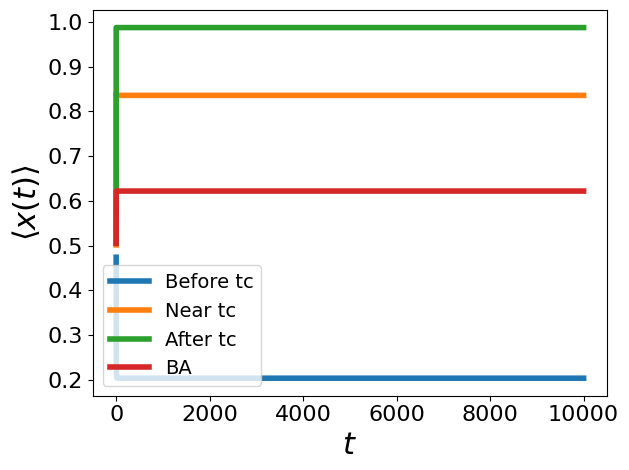

In [27]:
t = np.linspace(0, 10000, len(np.load("before_xtime.npy")))
# here beta = for this is 0.5 this was plotted 
plt.figure()
# beta =0.5
plt.plot(t, np.load("before_xtime.npy"), lw=4, label="Before tc")
plt.plot(t, np.load("near_xtime.npy"),   lw=4, label="Near tc")
plt.plot(t, np.load("after_xtime.npy"),  lw=4, label="After tc")
plt.plot(t, np.load("ba_xtime.npy"),     lw=4, label="BA")

plt.xlabel(r"$t$", fontsize=22, fontweight="bold")
plt.ylabel(r"$\langle x(t) \rangle$", fontsize=22, fontweight="bold")
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()


In [17]:
def triangle_density(A):
    N = len(A)
    A2 = A @ A
    return (A2 * A).sum() / (N * (N - 1))
def clustering_coeff(A):
    Und = ((A + A.T) > 0).astype(int)
    G = nx.from_numpy_array(Und)
    return nx.average_clustering(G)



--- Before $t_c$ ---
Triangle Density Δ = 0.0005268199233716475
Clustering C = 0.08571428571428572
Mean degree = 1.1241379310344828
Max degree = 5.0


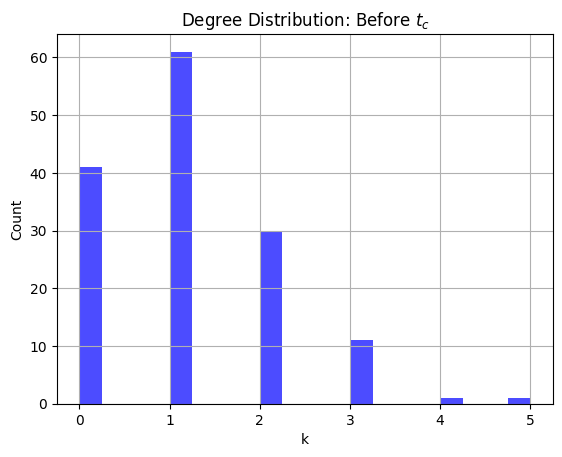


--- Near $t_c$ ---
Triangle Density Δ = 0.37472532610220205
Clustering C = 0.30029888749881783
Mean degree = 17.170648464163822
Max degree = 98.0


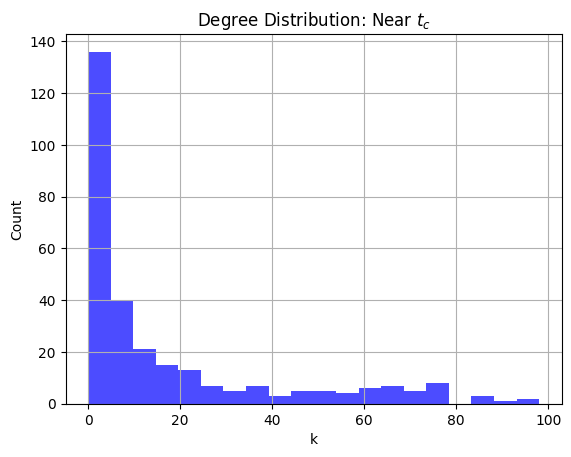


--- After $t_c$ ---
Triangle Density Δ = 74.08658955565735
Clustering C = 0.8655375080146218
Mean degree = 168.9358108108108
Max degree = 197.0


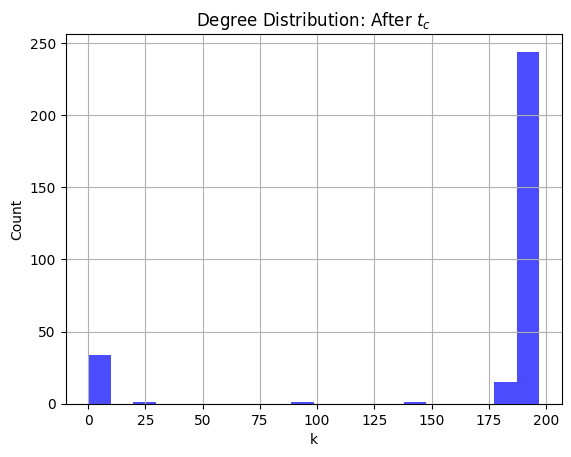

In [18]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

A_before = np.loadtxt("A_before_GCC.csv", delimiter=",")
A_near   = np.loadtxt("A_near_GCC.csv", delimiter=",")
A_after  = np.loadtxt("A_after_GCC.csv", delimiter=",")

for name, A in [
    ("Before $t_c$", A_before),
    ("Near $t_c$",   A_near),
    ("After $t_c$",  A_after)
]:
    Δ = triangle_density(A)
    C = clustering_coeff(A)
    deg = degree_distribution(A)

    print("\n---", name, "---")
    print("Triangle Density Δ =", Δ)
    print("Clustering C =", C)
    print("Mean degree =", deg.mean())
    print("Max degree =", deg.max())

    # plot degree histogram
    plt.figure()
    plt.hist(deg, bins=20, color="blue", alpha=0.7)
    plt.title(f"Degree Distribution: {name}")
    plt.xlabel("k")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

def degree_distribution_undirected(A):
    """
    Take a (possibly directed) adjacency matrix A,
    convert to undirected, and return node degrees.
    """
    Und = ((A + A.T) > 0).astype(int)
    deg = Und.sum(axis=1)
    return deg

def power_law_fit(deg, label="", k_min=3):
    """
    Compute P(k), plot log–log, and fit a power law tail P(k) ~ k^-gamma.
    """
    # degree histogram
    k_vals, counts = np.unique(deg, return_counts=True)
    P_k = counts / counts.sum()

    # print some basic info
    print(f"\n=== {label} ===")
    print("Degrees (k):", k_vals)
    print("P(k):", P_k)

    # log–log scatter
    plt.figure(figsize=(6,5))
    plt.scatter(k_vals, P_k, s=30)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Degree k (log scale)", fontsize=14)
    plt.ylabel("P(k) (log scale)", fontsize=14)
    plt.title(f"Degree distribution (log–log) — {label}", fontsize=14)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    # ----- power-law fit on tail k >= k_min -----
    mask = k_vals >= k_min
    if mask.sum() < 3:
        print(f"Not enough points in tail (k >= {k_min}) to fit.")
        return None

    k_tail = k_vals[mask]
    P_tail = P_k[mask]

    log_k = np.log(k_tail)
    log_P = np.log(P_tail)

    slope, intercept = np.polyfit(log_k, log_P, 1)
    gamma_est = -slope

    print(f"Estimated power-law exponent gamma ≈ {gamma_est:.3f} (fit for k ≥ {k_min})")

    # plot tail with fitted line
    plt.figure(figsize=(6,5))
    plt.scatter(k_tail, P_tail, s=30, label="Data")
    plt.plot(k_tail, np.exp(intercept + slope*log_k),
             label=f"Fit: P(k) ~ k^{slope:.2f}", lw=2)

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Degree k (log scale)", fontsize=14)
    plt.ylabel("P(k) (log scale)", fontsize=14)
    plt.title(f"Power-law tail fit — {label}", fontsize=14)
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    return gamma_est


Before tc: N = 145 mean k = 2.2482758620689656
Near   tc: N = 293 mean k = 33.54266211604096
After  tc: N = 296 mean k = 243.77702702702703

=== DPT GCC Before $t_c$ ===
Degrees (k): [1 2 3 4 5 6 7]
P(k): [0.33793103 0.27586207 0.24827586 0.09655172 0.02758621 0.00689655
 0.00689655]


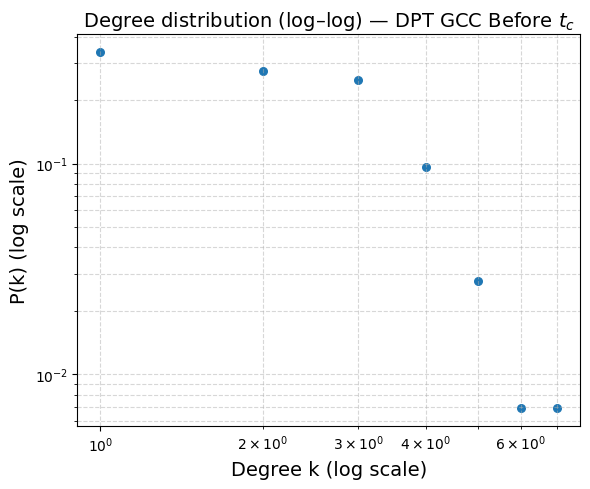

Estimated power-law exponent gamma ≈ 4.670 (fit for k ≥ 3)


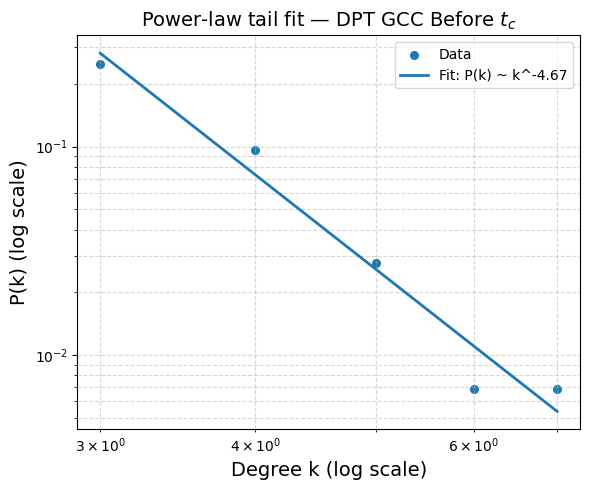


=== DPT GCC Near $t_c$ ===
Degrees (k): [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  50  51  52  53  54  55
  57  58  59  60  61  62  63  64  65  67  68  69  70  72  73  75  76  77
  79  80  81  87  88  89  90  91  92  93  96  97  98 105 106]
P(k): [0.06143345 0.04095563 0.03071672 0.00682594 0.03071672 0.03412969
 0.01706485 0.02047782 0.01706485 0.01023891 0.01706485 0.02047782
 0.01706485 0.02047782 0.01365188 0.01365188 0.02389078 0.00341297
 0.01706485 0.01365188 0.01023891 0.01023891 0.01706485 0.01365188
 0.01706485 0.01023891 0.01023891 0.01023891 0.00341297 0.02389078
 0.00682594 0.00341297 0.01706485 0.00682594 0.00682594 0.02047782
 0.00341297 0.00341297 0.00682594 0.00682594 0.00682594 0.00341297
 0.01023891 0.00341297 0.01023891 0.01365188 0.01365188 0.01023891
 0.01706485 0.00682594 0.00682594 0.00682594 0.00682594 0.02047

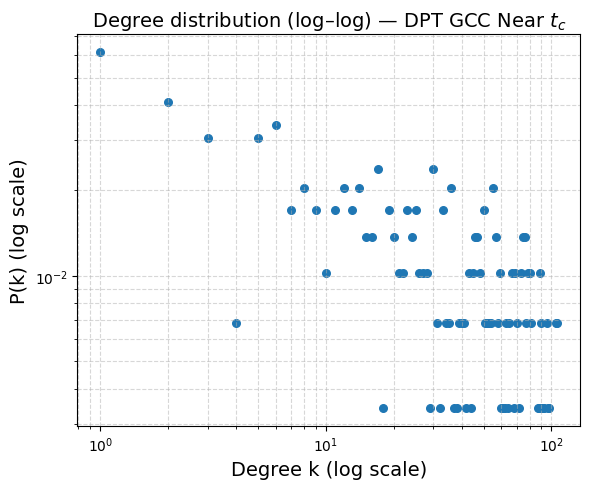

Estimated power-law exponent gamma ≈ 0.463 (fit for k ≥ 3)


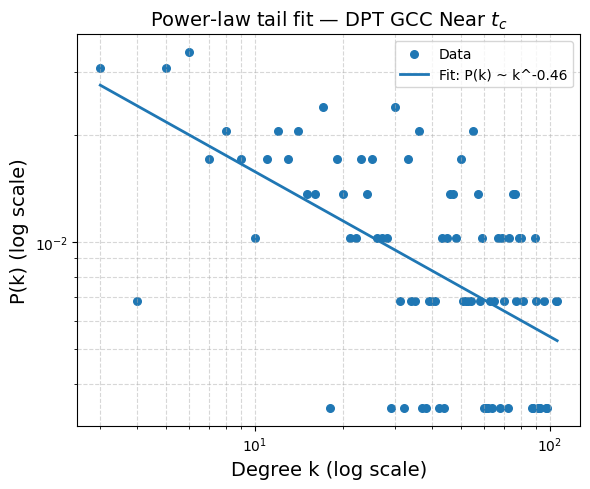


=== DPT GCC After $t_c$ ===
Degrees (k): [  1   2  29  67 186 187 188 189 190 191 192 193 194 195 196 197 199 200
 201 202 203 204 205 206 207 208 209 210 234 241 251 252 253 255 256 257
 258 259 260 261 262 263 264 265 266 267 268 269 270 271 272 273 274 275
 276 277]
P(k): [0.00337838 0.00337838 0.00337838 0.00337838 0.00337838 0.00337838
 0.00337838 0.00337838 0.01689189 0.02364865 0.01013514 0.02027027
 0.02027027 0.02027027 0.00675676 0.02027027 0.00337838 0.01013514
 0.00675676 0.00675676 0.01351351 0.01013514 0.01689189 0.01689189
 0.00337838 0.00337838 0.01689189 0.00337838 0.00337838 0.00337838
 0.00337838 0.00675676 0.00675676 0.00337838 0.00675676 0.03040541
 0.01689189 0.03378378 0.02027027 0.05067568 0.05067568 0.04391892
 0.04054054 0.06756757 0.06418919 0.06081081 0.0472973  0.04391892
 0.03040541 0.02364865 0.01689189 0.02027027 0.00337838 0.01351351
 0.00337838 0.00675676]


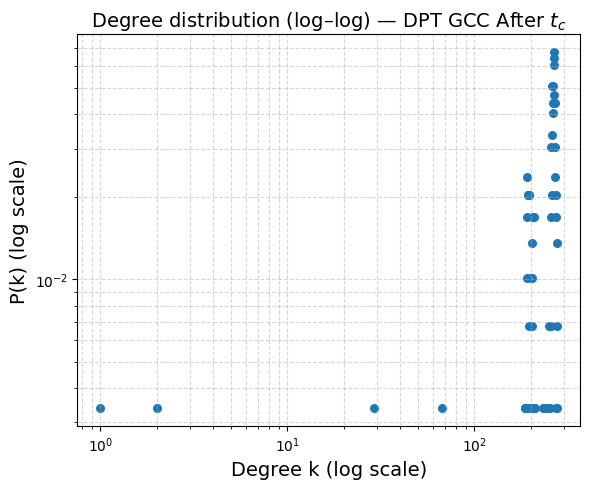

Estimated power-law exponent gamma ≈ -1.024 (fit for k ≥ 3)


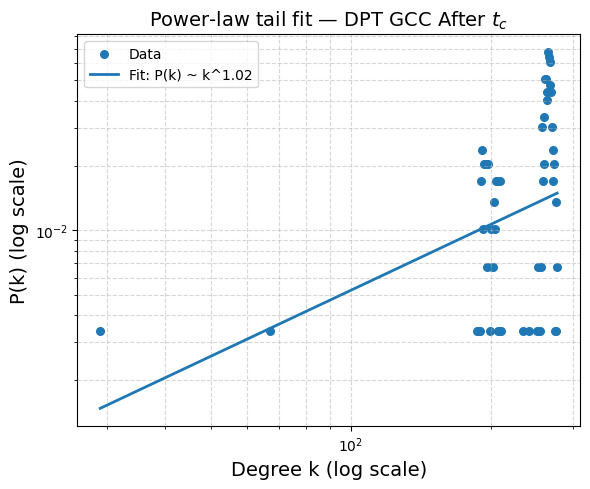


Estimated exponents:
Before tc gamma ≈ 4.670353196214366
Near   tc gamma ≈ 0.46334309957841197
After  tc gamma ≈ -1.0238288804937448


In [20]:
# Load GCC adjacency matrices you saved earlier
A_before = np.loadtxt("A_before_GCC.csv", delimiter=",")
A_near   = np.loadtxt("A_near_GCC.csv", delimiter=",")
A_after  = np.loadtxt("A_after_GCC.csv", delimiter=",")

# Compute degrees (undirected) for each
deg_before = degree_distribution_undirected(A_before)
deg_near   = degree_distribution_undirected(A_near)
deg_after  = degree_distribution_undirected(A_after)

# Print some quick stats
print("Before tc: N =", len(deg_before), "mean k =", deg_before.mean())
print("Near   tc: N =", len(deg_near),   "mean k =", deg_near.mean())
print("After  tc: N =", len(deg_after),  "mean k =", deg_after.mean())

# Fit power-law (tail) and plot for each
gamma_before = power_law_fit(deg_before, label="DPT GCC Before $t_c$", k_min=3)
gamma_near   = power_law_fit(deg_near,   label="DPT GCC Near $t_c$",   k_min=3)
gamma_after  = power_law_fit(deg_after,  label="DPT GCC After $t_c$",  k_min=3)

print("\nEstimated exponents:")
print("Before tc gamma ≈", gamma_before)
print("Near   tc gamma ≈", gamma_near)
print("After  tc gamma ≈", gamma_after)



=== Barabási–Albert ===
Degrees (k): [ 3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 21 25 26 27 34 35 37 38
 60]
P(k): [0.39666667 0.17333333 0.13333333 0.06333333 0.05666667 0.03666667
 0.02       0.02666667 0.02       0.00666667 0.00666667 0.00666667
 0.00666667 0.00666667 0.00333333 0.00666667 0.00333333 0.00333333
 0.00333333 0.00333333 0.00333333 0.00333333 0.00333333 0.00333333
 0.00333333]


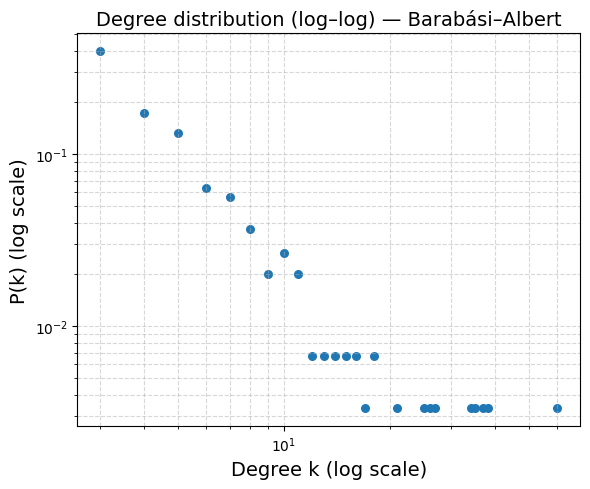

Estimated power-law exponent gamma ≈ 1.776 (fit for k ≥ 3)


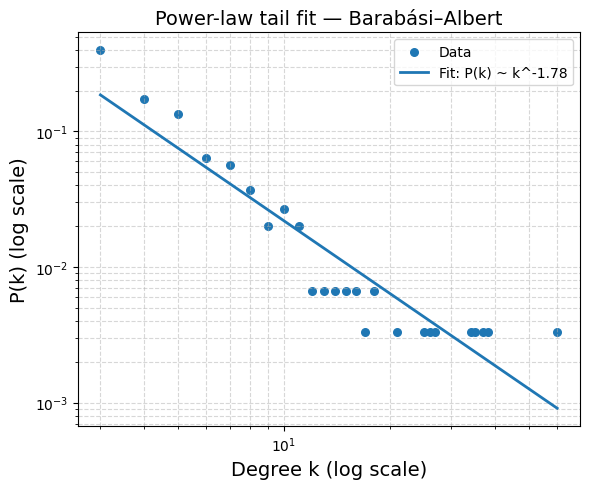

In [21]:
N = 300
m = 3
G_ba = nx.barabasi_albert_graph(N, m)
A_ba = nx.to_numpy_array(G_ba)
deg_ba = A_ba.sum(axis=1).astype(int)
gamma_ba = power_law_fit(deg_ba, label="Barabási–Albert", k_min=3)



=== Barabási–Albert ===
Degrees (k): [  0   1   3  29  94 139 182 184 186 187 188 189 190 191 192 193 194 195
 196 197]
P(k): [0.09797297 0.01351351 0.00337838 0.00337838 0.00337838 0.00337838
 0.00337838 0.00337838 0.01013514 0.03378378 0.04054054 0.0777027
 0.07094595 0.09459459 0.14189189 0.11824324 0.12162162 0.0777027
 0.05067568 0.03040541]


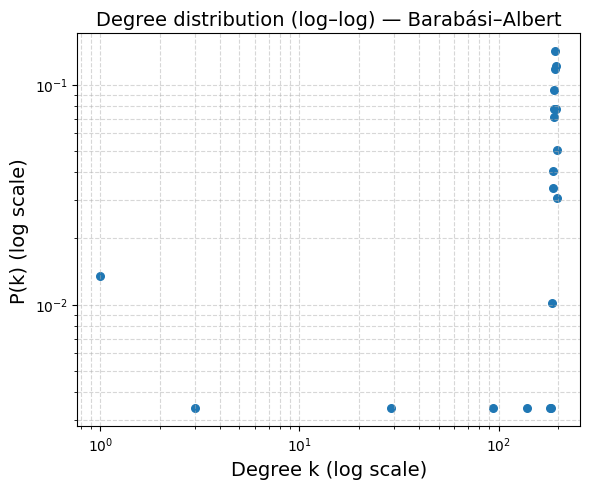

Estimated power-law exponent gamma ≈ -0.738 (fit for k ≥ 3)


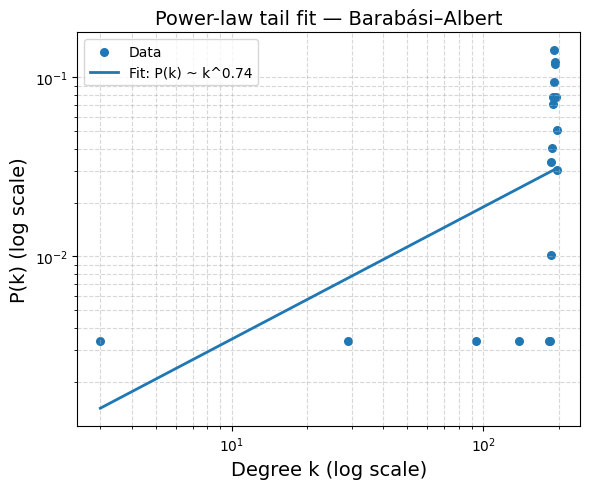

BA gamma ≈ -0.7379615521476192


In [22]:
deg_ba = A.sum(axis=1).astype(int)  # BA is already undirected

gamma_ba = power_law_fit(deg_ba, label="Barabási–Albert", k_min=3)
print("BA gamma ≈", gamma_ba)
